In [1]:
# 2D CNN — EfficientNet-B0 on HMS spectrograms (WORKSHOP VERSION, self-contained)
# Single-stage training, workshop-scale data (600 train / 120 val rows)
#
# Rationale for no 2-step: 2-step training rescues minority-class knowledge from a large,
# class-imbalanced dataset (Seizure ~256 vs Other ~3050 in the full data). The workshop subset
# is already balanced (100 rows/class train, 20 rows/class val), so there is no imbalance to
# correct for — a single training stage is sufficient here.
#
# This notebook is fully self-contained — no external .py imports. All classes and functions
# are defined inline below so you can read, tweak, and re-run any part of the pipeline directly.
!pip install timm -q

In [2]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
import timm

IS_KAGGLE = os.path.exists('/kaggle')
print(f"Environment: {'Kaggle' if IS_KAGGLE else 'Local'} | torch {torch.__version__}")

Environment: Kaggle | torch 2.10.0+cu128


In [3]:
# ============ Config ============
from dataclasses import dataclass, field

@dataclass
class Config2D:
    # ── Data paths ──────────────────────────────────────────────
    spectrogram_dir: str = "train_spectrograms"
    spec_cache_dir:  str = "/kaggle/working/spec_cache"

    # ── Spectrogram image dimensions ────────────────────────────────────────
    img_height: int = 100   # freq bins per chain (4 chains stacked → 400 total rows)
    img_width:  int = 300   # time columns per window (2-s resolution → 300 = 600 s)

    # ── Model ───────────────────────────────────────────────────────
    backbone:    str  = "efficientnet_b0"
    pretrained:  bool = True
    num_classes: int  = 6

    # ── Training ──────────────────────────────────────────────
    batch_size:   int   = 32
    lr:           float = 1e-3
    weight_decay: float = 1e-4

    # ── Early stopping ───────────────────────────────────────────
    patience: int = 10

    # ── Misc ──────────────────────────────────────────────────────
    seed:        int = 42
    num_workers: int = 2

    device: str = field(init=False)

    def __post_init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config2D()

if IS_KAGGLE:
    DATA_ROOT       = '/kaggle/input/competitions/hms-harmful-brain-activity-classification'
    RAW_TRAIN_PATH  = os.path.join(DATA_ROOT, 'train.csv')
    SAMPLE_IDS_PATH = '/kaggle/input/datasets/xiaosufrankhu/midas-summer-academy-wk3-eeg/workshop_sample_ids.csv'
    cfg.spectrogram_dir = os.path.join(DATA_ROOT, 'train_spectrograms')
else:
    DATA_ROOT       = os.path.abspath('../')
    RAW_TRAIN_PATH  = os.path.abspath('../data_raw/train.csv')
    SAMPLE_IDS_PATH = os.path.abspath('../data_raw/workshop_sample_ids.csv')
    cfg.spectrogram_dir = os.path.join(DATA_ROOT, 'train_spectrograms')

# ── reproducibility ───────────────────────────────────────────────────────────
random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device(cfg.device)
USE_AMP = DEVICE.type == 'cuda'

print(cfg)
print(f"Device: {DEVICE} | AMP: {USE_AMP}")

# NOTE: if running on Kaggle and this path doesn't exist, run !ls /kaggle/input
# and update DATA_ROOT to match how the competition data was attached.
print(f"Competition data path exists: {os.path.exists(DATA_ROOT)}")

Config2D(spectrogram_dir='/kaggle/input/competitions/hms-harmful-brain-activity-classification/train_spectrograms', spec_cache_dir='/kaggle/working/spec_cache', img_height=100, img_width=300, backbone='efficientnet_b0', pretrained=True, num_classes=6, batch_size=32, lr=0.001, weight_decay=0.0001, patience=10, seed=42, num_workers=2, device='cuda')
Device: cuda | AMP: True
Competition data path exists: True


In [4]:
# ============ Data loading (workshop subset) ============
# The raw HMS train.csv carries everything SpectrogramDataset needs (spectrogram_id,
# spectrogram_label_offset_seconds, vote columns). workshop_sample_ids.csv only carries
# ID + split, so we merge the two to reconstruct full rows for the 600/120 workshop subset.

raw_df     = pd.read_csv(RAW_TRAIN_PATH)
sample_ids = pd.read_csv(SAMPLE_IDS_PATH)

merged = raw_df.merge(
    sample_ids[["eeg_id", "eeg_sub_id", "split"]],
    on=["eeg_id", "eeg_sub_id"],
    how="inner",
)
train_df = merged[merged["split"] == "train"].reset_index(drop=True)
val_df   = merged[merged["split"] == "val"].reset_index(drop=True)

print(f'Train: {len(train_df):,} rows')
print(f'Val   : {len(val_df):,} rows')
print(train_df['expert_consensus'].value_counts())

Train: 600 rows
Val   : 120 rows
expert_consensus
LRDA       100
LPD        100
GPD        100
Other      100
Seizure    100
GRDA       100
Name: count, dtype: int64


In [5]:
# ============ Spectrogram preprocessing ============
# Kaggle's precomputed spectrograms already have 4 bipolar chains (LL, RL, LP, RP),
# each with 100 frequency bins, stacked into 400 rows per parquet file.
# We convert each {spec_id}.parquet → {spec_id}.npy once, then cache it.

def preprocess_one_spectrogram(spec_id: int, spectrogram_dir: str, cache_dir: str) -> None:
    dst = os.path.join(cache_dir, f"{spec_id}.npy")
    if os.path.exists(dst):
        return
    src = os.path.join(spectrogram_dir, f"{spec_id}.parquet")
    df  = pd.read_parquet(src)
    df  = df.fillna(0)
    if "time" in df.columns:
        df = df.drop(columns=["time"])
    # (total_time, 400) → transpose → (400, total_time)
    arr = df.to_numpy(dtype=np.float32).T
    np.save(dst, arr)


os.makedirs(cfg.spec_cache_dir, exist_ok=True)

# Workshop mode only needs the spectrograms actually used by the 720-row subset —
# far fewer than the full ~11,000 files, which keeps this step fast (seconds, not minutes).
needed_ids = set(train_df['spectrogram_id']).union(val_df['spectrogram_id'])
for spec_id in needed_ids:
    preprocess_one_spectrogram(int(spec_id), cfg.spectrogram_dir, cfg.spec_cache_dir)

print(f'Cache ready: {len(needed_ids)} spectrograms for workshop subset')

Cache ready: 206 spectrograms for workshop subset


In [6]:
# ============ Dataset ============
VOTE_COLS = ["seizure_vote", "lpd_vote", "gpd_vote",
             "lrda_vote",    "grda_vote", "other_vote"]


class SpectrogramDataset(Dataset):
    """
    Loads pre-cached (400, total_time) .npy spectrograms, extracts a 300-column
    (600-second) window around the labeled offset, normalizes it, and reshapes
    the 400 stacked rows back into 4 separate bipolar chains: (4, 100, 300).
    """

    def __init__(self, metadata_df: pd.DataFrame, spec_cache_dir: str):
        self.meta           = metadata_df.reset_index(drop=True)
        self.spec_cache_dir = spec_cache_dir

        votes    = self.meta[VOTE_COLS].to_numpy(dtype=np.float32)
        row_sums = votes.sum(axis=1, keepdims=True)
        row_sums = np.where(row_sums == 0, 1.0, row_sums)
        self.soft_labels = votes / row_sums          # (N, 6)
        self.hard_labels = self.soft_labels.argmax(1)  # (N,)

    def __len__(self) -> int:
        return len(self.meta)

    def __getitem__(self, idx: int) -> dict:
        row     = self.meta.iloc[idx]
        spec_id = int(row["spectrogram_id"])
        offset  = float(row["spectrogram_label_offset_seconds"])

        spec = np.load(os.path.join(self.spec_cache_dir, f"{spec_id}.npy"))

        # extract 300-column window; 2-second time resolution → col = offset // 2
        col_start = int(offset // 2)
        window    = spec[:, col_start:col_start + 300]   # (400, ≤300)

        # right-pad to exactly 300 columns if the window runs off the end
        if window.shape[1] < 300:
            pad    = 300 - window.shape[1]
            window = np.pad(window, ((0, 0), (0, pad)), mode="constant")

        # normalize: clip → log → z-score
        window = np.clip(window, np.exp(-4), np.exp(8))
        window = np.log(window)
        mu     = window.mean()
        sigma  = window.std()
        window = (window - mu) / (sigma + 1e-6)

        # split 400 stacked rows back into 4 chains: (400, 300) → (4, 100, 300)
        window = window.reshape(4, 100, 300)

        img   = torch.from_numpy(window).float()
        soft  = torch.from_numpy(self.soft_labels[idx])
        label = int(self.hard_labels[idx])

        return {"image": img, "soft_label": soft, "label": label}

In [7]:
# ============ Model ============
class EfficientNetEEG(nn.Module):
    """
    timm EfficientNet-B0 backbone adapted for 4-channel spectrogram input
    (instead of the usual 3-channel RGB), with a linear head for 6 classes.
    Pretrained on ImageNet — note the domain gap: natural images vs EEG spectrograms.
    """

    def __init__(self, backbone="efficientnet_b0", num_classes=6,
                 pretrained=True, drop_rate=0.3):
        super().__init__()
        self.encoder = timm.create_model(
            backbone,
            pretrained=pretrained,
            in_chans=4,       # 4 bipolar chains instead of RGB
            num_classes=0,    # remove timm's default head; add our own
            drop_rate=drop_rate,
        )
        n_features = self.encoder.num_features
        self.head = nn.Linear(n_features, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.encoder(x)
        return self.head(features)


model = EfficientNetEEG(
    backbone    = cfg.backbone,
    num_classes = cfg.num_classes,
    pretrained  = cfg.pretrained,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Backbone    : {cfg.backbone}")
print(f"Parameters  — total: {total_params:,} | trainable: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Backbone    : efficientnet_b0
Parameters  — total: 4,015,522 | trainable: 4,015,522


In [8]:
# ============ Single-stage training ============
GRAD_CLIP  = 1.0
NUM_EPOCHS = 5   # ~5-10 min on Kaggle T4 for this subset size
LR         = cfg.lr

criterion     = nn.KLDivLoss(reduction='batchmean')
val_criterion = nn.CrossEntropyLoss()
scaler        = torch.amp.GradScaler('cuda', enabled=USE_AMP)

history = []

train_ds     = SpectrogramDataset(train_df, cfg.spec_cache_dir)
train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
val_ds       = SpectrogramDataset(val_df, cfg.spec_cache_dir)
val_loader   = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
print(f'Train: {len(train_ds):,} | Val: {len(val_ds):,} | Epochs: {NUM_EPOCHS}')


def validate_2d(model, loader):
    model.eval()
    val_ce, val_kl = 0.0, 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            x    = batch['image'].to(DEVICE)
            y    = batch['label'].to(DEVICE)
            soft = batch['soft_label'].to(DEVICE)
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                logits = model(x)
            val_ce += val_criterion(logits, y).item()
            val_kl += criterion(F.log_softmax(logits, dim=1), soft).item()
            all_preds .extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    return (val_kl / len(loader),
            val_ce / len(loader),
            f1_score(all_labels, all_preds, average='macro', zero_division=0))


optimizer = AdamW(model.parameters(), lr=LR, weight_decay=cfg.weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
best_f1, best_epoch, wait = 0.0, 0, 0
best_state = None

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    t0 = time.time()
    train_loss = 0.0
    for batch in train_loader:
        x    = batch['image'].to(DEVICE)
        soft = batch['soft_label'].to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            logits = model(x)
            loss   = criterion(F.log_softmax(logits, dim=1), soft)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()
    scheduler.step()

    val_kl, val_ce, macro_f1 = validate_2d(model, val_loader)
    avg_train = train_loss / len(train_loader)
    elapsed   = time.time() - t0

    history.append({
        'epoch': epoch, 'train_kl': avg_train,
        'val_kl': val_kl, 'val_ce': val_ce, 'macro_f1': macro_f1,
    })
    print(f'Epoch {epoch:03d} | train_kl {avg_train:.4f} | '
          f'val_kl {val_kl:.4f} | val_ce {val_ce:.4f} | '
          f'macro_f1 {macro_f1:.4f} | {elapsed:.0f}s')

    if macro_f1 > best_f1:
        best_f1, best_epoch, wait = macro_f1, epoch, 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(model.state_dict(), 'best_2d_workshop.pt')
        print(f'  ✓ saved best_2d_workshop.pt (f1={best_f1:.4f})')
    else:
        wait += 1
        if wait >= cfg.patience:
            print(f'Early stopping at epoch {epoch}')
            break

print(f'\nTraining complete — best macro_f1={best_f1:.4f} at epoch {best_epoch}')
if best_state is not None:
    model.load_state_dict(best_state)

Train: 600 | Val: 120 | Epochs: 5
Epoch 001 | train_kl 0.7205 | val_kl 1.3693 | val_ce 2.2202 | macro_f1 0.1489 | 25s
  ✓ saved best_2d_workshop.pt (f1=0.1489)
Epoch 002 | train_kl 0.3151 | val_kl 1.0349 | val_ce 1.7212 | macro_f1 0.3094 | 2s
  ✓ saved best_2d_workshop.pt (f1=0.3094)
Epoch 003 | train_kl 0.1997 | val_kl 1.6216 | val_ce 2.4197 | macro_f1 0.2701 | 2s
Epoch 004 | train_kl 0.1380 | val_kl 1.2520 | val_ce 2.0317 | macro_f1 0.2243 | 2s
Epoch 005 | train_kl 0.0936 | val_kl 1.2797 | val_ce 2.0962 | macro_f1 0.2297 | 2s

Training complete — best macro_f1=0.3094 at epoch 2


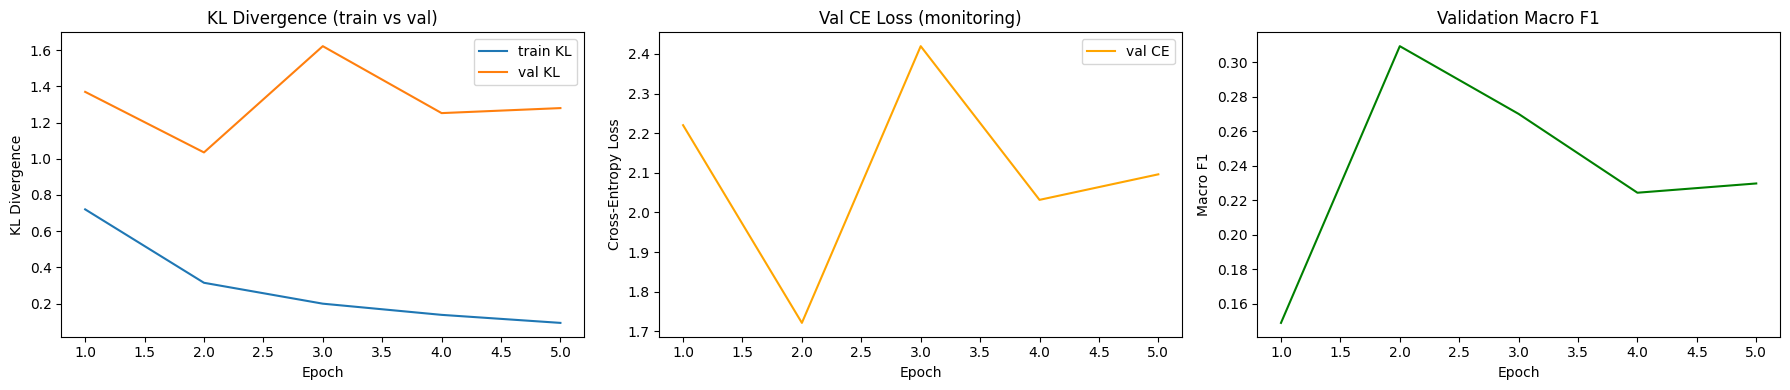


Final epoch summary:
  Best macro_f1 : 0.3094  (epoch 2)
  Best val KL   : 1.0349  (epoch 2)
  Final val KL  : 1.2797


In [9]:
epochs_   = [h['epoch']    for h in history]
train_kl_ = [h['train_kl'] for h in history]
val_kl_   = [h['val_kl']   for h in history]
val_ce_   = [h['val_ce']   for h in history]
macro_f1_ = [h['macro_f1'] for h in history]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(epochs_, train_kl_, label='train KL')
ax1.plot(epochs_, val_kl_,   label='val KL')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('KL Divergence')
ax1.set_title('KL Divergence (train vs val)'); ax1.legend()

ax2.plot(epochs_, val_ce_, color='orange', label='val CE')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-Entropy Loss')
ax2.set_title('Val CE Loss (monitoring)'); ax2.legend()

ax3.plot(epochs_, macro_f1_, color='green')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Macro F1')
ax3.set_title('Validation Macro F1')

plt.tight_layout()
plt.savefig('training_curves_2d_workshop.png', dpi=150)
plt.show()

print(f'\nFinal epoch summary:')
print(f'  Best macro_f1 : {max(macro_f1_):.4f}  (epoch {epochs_[macro_f1_.index(max(macro_f1_))]})')
print(f'  Best val KL   : {min(val_kl_):.4f}  (epoch {epochs_[val_kl_.index(min(val_kl_))]})')
print(f'  Final val KL  : {val_kl_[-1]:.4f}')